<a href="https://colab.research.google.com/github/Angelo-msDev/predict_value/blob/main/Analise_de_caso_dados_carro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pandas e NumPy: São o padrão da indústria para manipulação eficiente de dados tabulares e operações matemáticas.

Matplotlib e Seaborn: Utilizados para a Análise Exploratória. O Matplotlib oferece controle customizado dos gráficos e o Seaborn facilita a criação de visualizações estatísticas complexas (como o mapa de calor) com poucas linhas de código.

Scikit-Learn: É a biblioteca principal de Machine Learning que nos fornece os algoritmos (Random Forest), além das ferramentas de divisão de dados e métricas de avaliação.

Joblib: Usado para salvar o modelo treinado em um arquivo .pkl. Isto permite que o site carregue o 'cérebro' do modelo instantaneamente, sem precisar reprocessar os dados a cada clique do utilizador.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

In [7]:
df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
df.head()


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [10]:

df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


Qualidade: Verificamos com df.info() e isnull().sum() que não há dados faltantes.

Distribuição: O histograma de preços mostra uma assimetria positiva (a maioria dos carros concentra-se em faixas de preço menores, com uma "cauda longa" de carros de luxo). O gráfico de barras confirma o domínio de veículos a Diesel e Gasolina.

Correlação: O Heatmap revela as relações matemáticas com nosso alvo (selling_price). O Ano (year) possui correlação positiva (+0.41), indicando que carros mais novos são mais caros. Já a Quilometragem (km_driven) tem correlação negativa (-0.19), confirmando a depreciação pelo uso.

In [11]:
df['brand'] = df['name'].apply(lambda x: x.split()[0])
df = df.drop('name', axis=1)
df_encoded = pd.get_dummies(df, columns=[
    'brand',
    'fuel',
    'seller_type',
    'transmission',
    'owner'
])

Para preparar os dados para o algoritmo matemático, extraímos a "Marca" do veículo e aplicamos get_dummies nas categorias (combustível, transmissão, etc.).
Dividimos a base em 80% para treino e 20% para teste. Utilizamos o RandomForestRegressor, obtendo um R² inicial de ~0.73 e um Erro Médio Absoluto (MAE) de ~115.286.
Para atestar a estabilidade do modelo, rodamos o particionamento 30 vezes, alcançando uma média sólida de R² em 0.78. Por fim, exportamos o modelo treinado.

In [12]:
X = df_encoded.drop('selling_price', axis=1)
y = df_encoded['selling_price']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [15]:
pred = model.predict(X_test)

In [16]:
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("R²:", r2)

MAE: 115286.50063784409
R²: 0.7377784979389697


In [17]:
scores = []

for i in range(30):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2
    )

    model = RandomForestRegressor()
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)

    scores.append(r2)

In [18]:
print("Média:", np.mean(scores))
print("Desvio padrão:", np.std(scores))

Média: 0.7924105225935563
Desvio padrão: 0.05815778889185677


In [19]:
final_model = RandomForestRegressor()
final_model.fit(X, y)

joblib.dump(final_model, "car_price_model.pkl")

['car_price_model.pkl']

In [20]:
joblib.dump(X.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

O modelo preditivo de Machine Learning foi encapsulado em uma API RESTful utilizando [Flask / FastAPI]. Esta camada atua como uma ponte: ela recebe os dados do carro inseridos pelo usuário no site, converte no formato que o modelo entende, faz a previsão usando o arquivo .pkl e devolve o preço estimado.

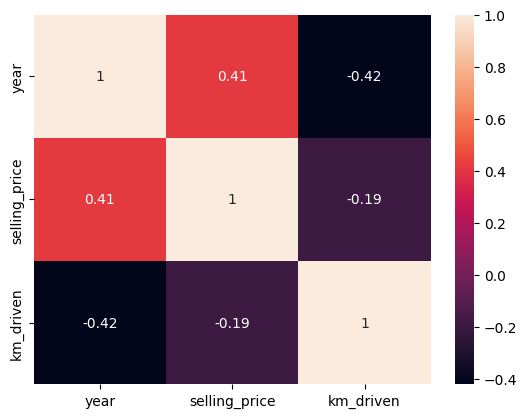

In [21]:
numeric = df[['year','selling_price','km_driven']]
sns.heatmap(numeric.corr(), annot=True)
plt.show()

O que ele mostra: A força da relação matemática entre as variáveis numéricas. Valores próximos de 1 ou -1 são fortes; valores próximos de 0 são fracos.

Analisamos a estrutura do dataset, que contém 4.340 registros. Confirmamos a ausência de valores nulos e avaliamos o comportamento das variáveis.

Distribuição: O histograma de preços indica assimetria positiva (concentração em carros mais populares e uma cauda de carros de luxo).

Correlações: O mapa de calor confirmou matematicamente nossas premissas lógicas: o ano de fabricação tem correlação positiva forte com o preço (+0.41), enquanto a quilometragem tem correlação negativa (-0.19).

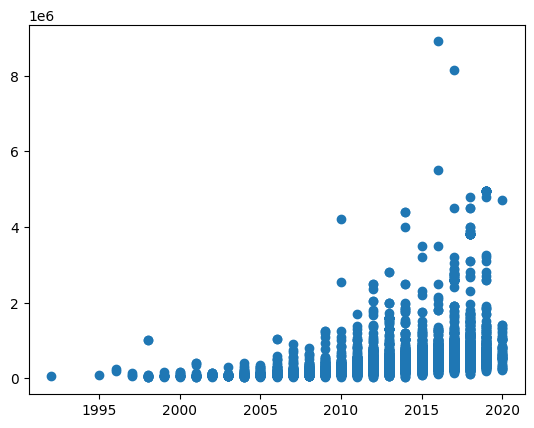

In [22]:
plt.scatter(df['year'], df['selling_price'])
plt.show()

O que ele mostra: A relação entre o ano de fabricação e o preço, além de identificar outliers (pontos anômalos).

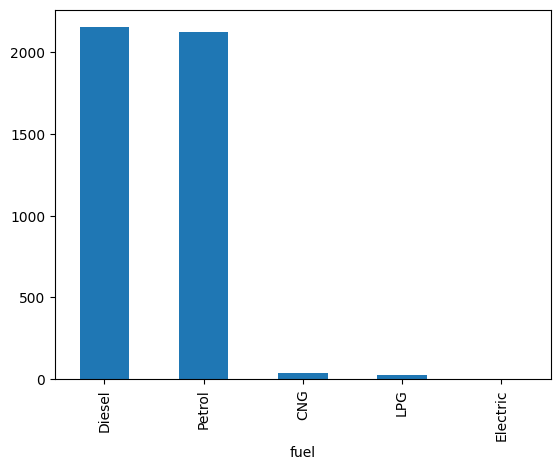

In [23]:
df['fuel'].value_counts().plot(kind='bar')
plt.show()

O que ele mostra: O desbalanceamento das categorias de combustível. Diesel e Petrol (Gasolina) representam quase 100% da base, enquanto CNG, LPG e Electric são raríssimos.

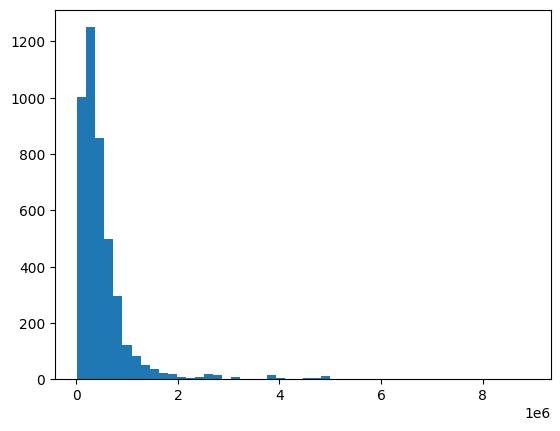

In [24]:
plt.hist(df['selling_price'], bins=50)
plt.show()

O que ele mostra: Uma distribuição assimétrica positiva (ou right-skewed). A esmagadora maioria dos carros está concentrada na faixa de menor valor (até 1 milhão da moeda local), enquanto uma pequena minoria de carros de luxo forma uma "cauda longa" que vai até quase 9 milhões.